# cc-1.2 — retail Stage-1 **Act-PRM EM** analysis

Stage-1 trains a LoRA *thought generator* so action-only logs get plausible
thoughts. Per logged action `x` in state `s`: sample G thoughts `z`, reward =
length-penalized `p(x | s, z)` (`*/try_0/final_reward`), group-normalize to EM
weights, PG step on the `(thought + action)` tokens.

Two scorers (see `notes/cc-1.0`, `cc-2.0`):
- **policy** (`swb=0`, `--no-score_with_base`): the current LoRA scores.
- **base** (`swb=1`, `--score_with_base`): the frozen base Qwen3-4B scores.

Key finding to visualize (`notes/cc-4.0`): held-out reward **peaks early
(~batch 5)** then *declines* — the EM reward overfits/drifts. That is why we
relabel the SFT corpus from **both** `step_best` (the peak) and `step_last`
(fully trained) — the `_last` SFT arms in `cc-1.1`.

Auto-discovers the EM run dirs and degrades gracefully (skips empty runs).

In [1]:
# === CONFIG =================================================================
from pathlib import Path  # (also imported in the SETUP cell below; safe)


def _repo_root(start=None):
    # Walk up to the repo root (dir with pyproject.toml + notebooks/) so paths
    # resolve whether launched from the repo root or from notebooks/.
    p = (Path(start) if start else Path.cwd()).resolve()
    for c in (p, *p.parents):
        if (c / "pyproject.toml").exists() and (c / "notebooks").exists():
            return c
    return Path.cwd()


REPO = _repo_root()
LOGROOT = REPO / "logs" / "act_prm_tau2_retail" / "hf_qwen3_4b_instruct"

# Stage-1 EM dirs use the default run_name (start with 'act-prm-'), carry
# '-gc=act_prm-' (NOT act_prm_actions_only) and have no _s2_/s1relabel tag.
EM_GLOB = "act-prm-*"

print("LOGROOT:", LOGROOT, "| exists:", LOGROOT.exists())

LOGROOT: /home/mzio/projects/act-prm-blog/logs/act_prm_tau2_retail/hf_qwen3_4b_instruct | exists: True


In [2]:
# === SETUP: headless backend + imports =======================================
import matplotlib
# Non-interactive rendering: the inline backend (Agg-based) is headless AND
# embeds figures as PNGs under nbconvert/jupyter; fall back to bare Agg if we
# are not running inside an IPython kernel.
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    matplotlib.use("Agg")

import json, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True,
                     "grid.alpha": 0.3, "figure.dpi": 110})

# Brand-neutral, colorblind-safe categorical palette.
PALETTE = ["#4C78A8", "#F58518", "#54A24B", "#B279A2", "#E45756", "#72B7B2"]


def load_metrics(mfile) -> pd.DataFrame:
    """Load a run's metrics.jsonl -> DataFrame, deduped on progress/batch
    (keep last: the eval flush writes a partial row before the merged one).
    Returns an empty frame (no exception) if the file is missing/empty."""
    mfile = Path(mfile)
    if not mfile.is_file():
        return pd.DataFrame()
    rows = []
    for line in mfile.read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except Exception:
            pass
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    if "progress/batch" in df:
        df = (df.drop_duplicates("progress/batch", keep="last")
                .sort_values("progress/batch").reset_index(drop=True))
    return df


def _xy(df, col, xcol="progress/batch"):
    """(x, y) for a metric column, dropping rows where it is NaN/absent."""
    if df is None or df.empty or col not in df:
        return None, None
    keep = [c for c in (xcol, col) if c in df]
    sub = df[keep].dropna()
    if sub.empty:
        return None, None
    x = sub[xcol] if xcol in sub else np.arange(len(sub))
    return x, sub[col]


In [3]:
# === DISCOVER EM runs, classify by scorer (swb) ==============================
def parse_em(name: str):
    """Return (label, style_key) for an EM run dir name, or None to skip."""
    if "act_prm_actions_only" in name or "s1relabel" in name or "_s2_" in name:
        return None
    if "-gc=act_prm-" not in name:
        return None
    swb = re.search(r"swb=(\d)", name)
    scorer = "base" if (swb and swb.group(1) == "1") else "policy"
    tags = []
    if "omc=" in name:
        tags.append("obs-capped")
    label = scorer + (f" ({', '.join(tags)})" if tags else "")
    return label, scorer


def discover_em(logroot: Path, glob: str) -> dict:
    runs = {}
    if not logroot.exists():
        warnings.warn(f"log root missing: {logroot}")
        return runs
    for d in sorted(logroot.glob(glob)):
        if not d.is_dir():
            continue
        parsed = parse_em(d.name)
        if parsed is None:
            continue
        label, scorer = parsed
        df = load_metrics(d / "metrics.jsonl")
        # keep only runs that actually have rows
        runs[label] = {"df": df, "scorer": scorer, "dir": d,
                       "n": 0 if df.empty else len(df)}
    # drop empty runs but keep a note
    empties = [k for k, v in runs.items() if v["df"].empty]
    for k in empties:
        print(f"skip (no metrics yet): {k}  [{runs[k]['dir'].name[:50]}...]")
        del runs[k]
    return runs


SCORER_COLOR = {"policy": PALETTE[0], "base": PALETTE[1]}
EM = discover_em(LOGROOT, EM_GLOB)
if not EM:
    print("No EM runs with metrics found yet.")
else:
    for lbl, m in EM.items():
        print(f"{lbl:22s} rows={m['n']:3d}  ({m['dir'].name[:55]}...)")

skip (no metrics yet): policy (obs-capped)  [act-prm-ia=0-rr=0-ec=act_prm_tau2_retail-gc=act_pr...]
policy                 rows= 25  (act-prm-ia=0-rr=0-ec=act_prm_tau2_retail-gc=act_prm-tc=...)
base                   rows= 25  (act-prm-ia=0-rr=0-ec=act_prm_tau2_retail-gc=act_prm-tc=...)


In [4]:
# === PLOT helper (color by scorer, train=dashed/eval=solid) =================
def plot_em(runs, col, title, ylabel, ax, kind="eval"):
    ls = "-" if kind == "eval" else "--"
    mk = "o" if kind == "eval" else "."
    plotted = 0
    for label, m in runs.items():
        x, y = _xy(m["df"], col)
        if x is None:
            continue
        ax.plot(x, y, ls=ls, marker=mk, ms=4, lw=1.6,
                color=SCORER_COLOR.get(m["scorer"], "#888"),
                label=f"{label} ({kind})")
        plotted += 1
    ax.set(title=title, xlabel="step (progress/batch)", ylabel=ylabel)
    if plotted:
        ax.legend(fontsize=7)
    else:
        ax.text(0.5, 0.5, "no data yet", ha="center", va="center",
                transform=ax.transAxes, color="gray")
    return ax

print("plot_em ready")

plot_em ready


## (a) Held-out EM reward `p(x | s, z)` vs step — the early peak

`eval/try_0/final_reward` is the length-penalized action likelihood on the
held-out `act_prm_eval` split; `eval/try_0/likelihood` is the raw likelihood.
Watch for the peak near batch ~5 followed by decline.

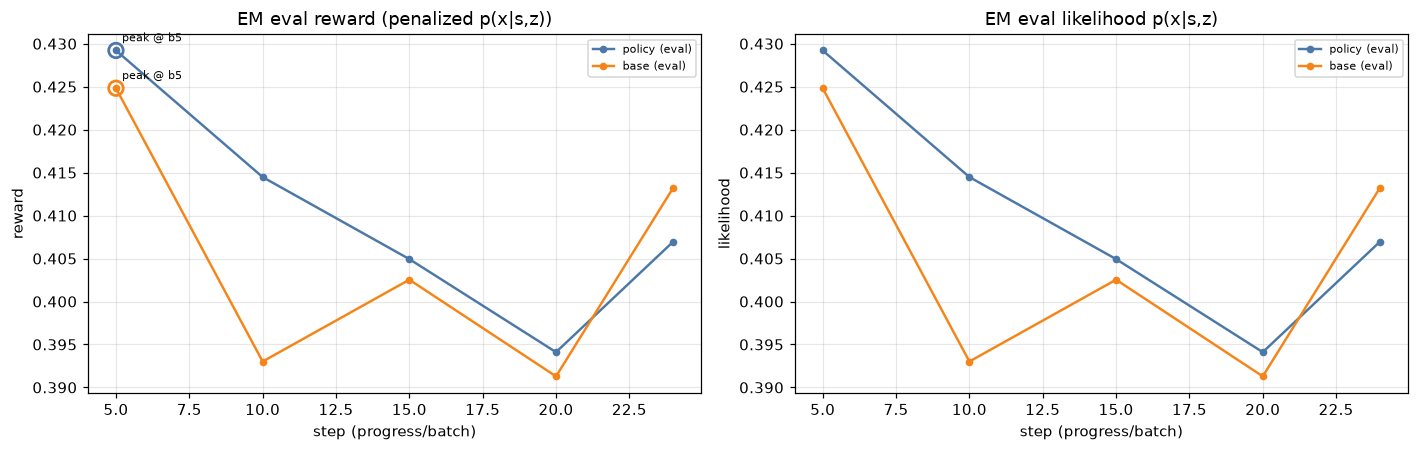

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
plot_em(EM, "eval/try_0/final_reward", "EM eval reward (penalized p(x|s,z))", "reward", axes[0], "eval")
plot_em(EM, "eval/try_0/likelihood",  "EM eval likelihood p(x|s,z)",         "likelihood", axes[1], "eval")

# annotate the argmax (peak) of eval reward per run
for label, m in EM.items():
    x, y = _xy(m["df"], "eval/try_0/final_reward")
    if x is None:
        continue
    xi, yi = np.asarray(x), np.asarray(y)
    j = int(np.argmax(yi))
    axes[0].scatter([xi[j]], [yi[j]], s=90, facecolors="none",
                    edgecolors=SCORER_COLOR.get(m["scorer"], "#888"), linewidths=1.8, zorder=5)
    axes[0].annotate(f"peak @ b{int(xi[j])}", (xi[j], yi[j]), fontsize=7,
                     xytext=(4, 6), textcoords="offset points")
plt.tight_layout(); plt.show()

## (b) Train vs held-out reward together

Train reward (`train/try_0/final_reward`, dashed) keeps climbing while held-out
reward (solid) turns over — the generalization gap that motivates `step_best`.

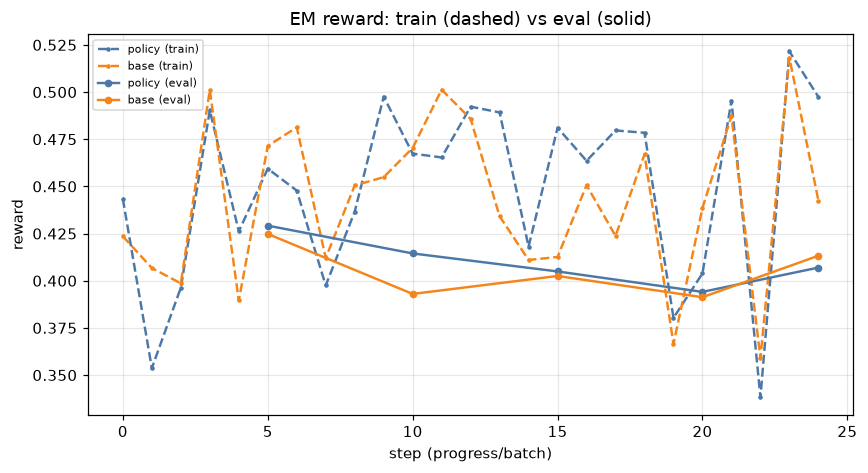

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.4))
plot_em(EM, "train/try_0/final_reward", "EM reward: train (dashed) vs eval (solid)", "reward", ax, "train")
plot_em(EM, "eval/try_0/final_reward",  "EM reward: train (dashed) vs eval (solid)", "reward", ax, "eval")
plt.tight_layout(); plt.show()

## (c) Thought-token length vs step

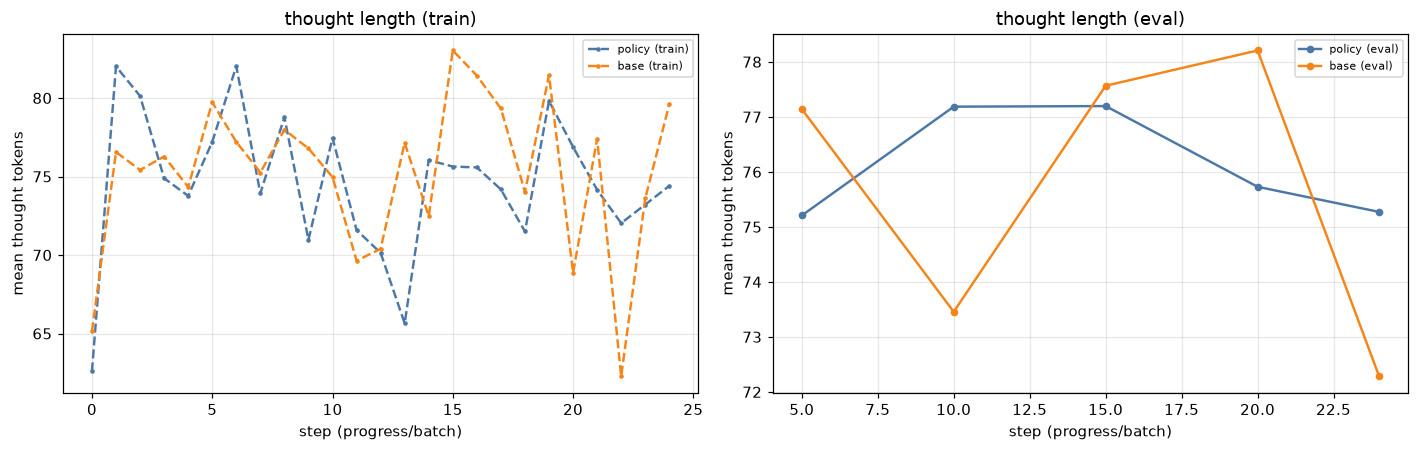

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
plot_em(EM, "train/try_0/thought_tokens", "thought length (train)", "mean thought tokens", axes[0], "train")
plot_em(EM, "eval/try_0/thought_tokens",  "thought length (eval)",  "mean thought tokens", axes[1], "eval")
plt.tight_layout(); plt.show()

In [8]:
# === Numeric summary: peak vs last held-out reward ==========================
rows = []
for label, m in EM.items():
    x, y = _xy(m["df"], "eval/try_0/final_reward")
    if x is None:
        continue
    xi, yi = np.asarray(x), np.asarray(y)
    j = int(np.argmax(yi))
    rows.append({"run": label, "peak_reward": round(float(yi[j]), 4),
                 "peak_step": int(xi[j]), "last_reward": round(float(yi[-1]), 4),
                 "last_step": int(xi[-1]),
                 "decline": round(float(yi[j] - yi[-1]), 4)})
if rows:
    display(pd.DataFrame(rows))
else:
    print("No held-out reward points yet.")

,run,peak_reward,peak_step,last_reward,last_step,decline
0,policy,0.4292,5,0.4070,24,0.0222
1,base,0.4248,5,0.4133,24,0.0116


## Interpretation

The held-out reward `p(x | s, z)` rises for only a few EM steps and then
**declines** (both scorers peak around batch ~5, then drift down by batch ~20).
The M-step keeps raising the *train* reward, so this is a generalization gap:
past the peak the thought generator is fitting the training logs, not producing
thoughts that transfer to held-out actions.

Consequence for the pipeline: the naive "train to the end then relabel" choice
(`step_last`) is *not* obviously the best thought generator. We therefore export
the SFT corpus from **both** checkpoints — `step_best` (peak held-out reward)
and `step_last` (fully trained) — and run them as separate SFT arms
(`thoughts_{policy,base}` vs `thoughts_{policy,base}_last` in `cc-1.1`), so the
downstream SFT metric decides which EM checkpoint actually yields the more useful
thoughts. Thought-length stays roughly flat, so the decline is not simply the
thoughts collapsing/blowing up in length.